# Data Visualtization


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

In [6]:
data = pd.read_csv('/home/san/Desktop/studentPerformance/datasets/StudentPerformanceFactors.csv')

In [7]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


### Note that its missing Object type columns, lets encode those object types to integer

In [10]:
# make a copy of the data and encode it.
data_copy = data.copy()
uncoded_columns = data.select_dtypes(include = 'object')
uncoded_columns

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,Low,High,No,Low,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
1,Low,Medium,No,Low,Yes,Medium,Medium,Public,Negative,No,College,Moderate,Female
2,Medium,Medium,Yes,Medium,Yes,Medium,Medium,Public,Neutral,No,Postgraduate,Near,Male
3,Low,Medium,Yes,Medium,Yes,Medium,Medium,Public,Negative,No,High School,Moderate,Male
4,Medium,Medium,Yes,Medium,Yes,Medium,High,Public,Neutral,No,College,Near,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,High,Medium,No,Medium,Yes,High,Medium,Public,Positive,No,High School,Near,Female
6603,High,Medium,No,Medium,Yes,Low,High,Public,Positive,No,High School,Near,Female
6604,Medium,Low,Yes,Low,Yes,Low,Medium,Public,Negative,No,Postgraduate,Near,Female
6605,High,High,Yes,High,Yes,Low,Medium,Private,Positive,No,High School,Far,Female


In [11]:
ordinal_encoder = OrdinalEncoder()
encoded_columns = ordinal_encoder.fit_transform(uncoded_columns)
encoded_columns

array([[1., 0., 0., ..., 1., 2., 1.],
       [1., 2., 0., ..., 0., 1., 0.],
       [2., 2., 1., ..., 2., 2., 1.],
       ...,
       [2., 1., 1., ..., 2., 2., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       [2., 1., 1., ..., 2., 2., 1.]], shape=(6607, 13))

In [12]:
# ordinal encoder returns numpy array, changing it to dataframe,
uncoded_columns = data.select_dtypes(include = 'object').columns

encoded_df = pd.DataFrame(encoded_columns,columns = uncoded_columns)
encoded_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Parental_Involvement,6607.0,1.220070,0.865634,0.0,0.0,2.0,2.0,2.0
Access_to_Resources,6607.0,1.203421,0.871783,0.0,0.0,2.0,2.0,2.0
Extracurricular_Activities,6607.0,0.596035,0.490728,0.0,0.0,1.0,1.0,1.0
Motivation_Level,6607.0,1.307553,0.782515,0.0,1.0,2.0,2.0,2.0
Internet_Access,6607.0,0.924474,0.264258,0.0,1.0,1.0,1.0,1.0
Family_Income,6607.0,1.211442,0.742264,0.0,1.0,1.0,2.0,2.0
Teacher_Quality,6529.0,1.302956,0.898729,0.0,0.0,2.0,2.0,2.0
School_Type,6607.0,0.695929,0.460048,0.0,0.0,1.0,1.0,1.0
Peer_Influence,6607.0,1.190858,0.755876,0.0,1.0,1.0,2.0,2.0
Learning_Disabilities,6607.0,0.105191,0.306823,0.0,0.0,0.0,0.0,1.0


In [13]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Parental_Involvement        6607 non-null   float64
 1   Access_to_Resources         6607 non-null   float64
 2   Extracurricular_Activities  6607 non-null   float64
 3   Motivation_Level            6607 non-null   float64
 4   Internet_Access             6607 non-null   float64
 5   Family_Income               6607 non-null   float64
 6   Teacher_Quality             6529 non-null   float64
 7   School_Type                 6607 non-null   float64
 8   Peer_Influence              6607 non-null   float64
 9   Learning_Disabilities       6607 non-null   float64
 10  Parental_Education_Level    6517 non-null   float64
 11  Distance_from_Home          6540 non-null   float64
 12  Gender                      6607 non-null   float64
dtypes: float64(13)
memory usage: 671.

In [14]:
encoded_df.isna().sum

<bound method DataFrame.sum of       Parental_Involvement  Access_to_Resources  Extracurricular_Activities  \
0                    False                False                       False   
1                    False                False                       False   
2                    False                False                       False   
3                    False                False                       False   
4                    False                False                       False   
...                    ...                  ...                         ...   
6602                 False                False                       False   
6603                 False                False                       False   
6604                 False                False                       False   
6605                 False                False                       False   
6606                 False                False                       False   

      Motivation_Lev

In [15]:
encoded_df.isna().sum().sum()

np.int64(235)

In [16]:
data_copy[uncoded_columns] = encoded_columns
data_copy.corr()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
Hours_Studied,1.000000,-0.009908,0.007207,-0.007909,-0.006017,0.010977,0.024846,0.022092,0.005038,-0.014282,0.010025,0.004782,0.000299,0.009698,0.004624,-0.014401,0.008480,-0.012466,-0.004241,0.445455
Attendance,-0.009908,1.000000,-0.004940,0.000862,-0.002222,-0.015918,-0.020186,0.013098,-0.018318,0.014324,-0.008097,-0.005079,-0.018645,-0.007519,-0.022435,-0.022231,0.015047,0.020264,0.008040,0.581072
Parental_Involvement,0.007207,-0.004940,1.000000,0.010476,0.022225,0.001280,0.005094,-0.013449,0.001863,-0.007655,0.005080,-0.004066,-0.003376,-0.008446,0.007986,-0.010800,0.017466,0.001255,0.024656,-0.094289
Access_to_Resources,-0.007909,0.000862,0.010476,1.000000,-0.009579,-0.004738,-0.002976,-0.010507,0.002304,0.010928,0.010485,0.012667,0.030449,0.009301,0.037976,0.004880,-0.009327,0.017247,0.006381,-0.090503
Extracurricular_Activities,-0.006017,-0.002222,0.022225,-0.009579,1.000000,0.001379,0.004354,-0.006758,-0.005345,0.003192,0.015102,-0.002437,0.005655,0.009142,-0.001032,-0.008288,-0.011534,-0.013818,0.007945,0.064382
Sleep_Hours,0.010977,-0.015918,0.001280,-0.004738,0.001379,1.000000,-0.021750,0.000257,0.011901,-0.012216,0.011030,-0.005395,0.002775,-0.016867,-0.000378,0.015392,-0.001543,0.002927,-0.007479,-0.017022
Previous_Scores,0.024846,-0.020186,0.005094,-0.002976,0.004354,-0.021750,1.000000,-0.021620,0.004304,-0.013122,0.011847,-0.021047,0.013452,-0.017982,-0.011274,0.007057,0.013187,0.006117,0.001021,0.175079
Motivation_Level,0.022092,0.013098,-0.013449,-0.010507,-0.006758,0.000257,-0.021620,1.000000,0.000343,-0.012456,-0.009552,0.012032,-0.005520,0.003372,-0.003599,-0.018126,0.020712,0.010750,0.001173,-0.014910
Internet_Access,0.005038,-0.018318,0.001863,0.002304,-0.005345,0.011901,0.004304,0.000343,1.000000,-0.010071,0.016600,-0.001705,0.012786,-0.010429,-0.012867,0.006517,0.022279,-0.010616,0.015139,0.051475
Tutoring_Sessions,-0.014282,0.014324,-0.007655,0.010928,0.003192,-0.012216,-0.013122,-0.012456,-0.010071,1.000000,-0.002109,-0.000932,0.008257,-0.005139,0.017733,0.007564,-0.000352,0.018079,-0.006734,0.156525


### Gives the general idea that , there arent many X that has extreme negative correlation with Y, so dropping such Features wouldnt be much wise decision

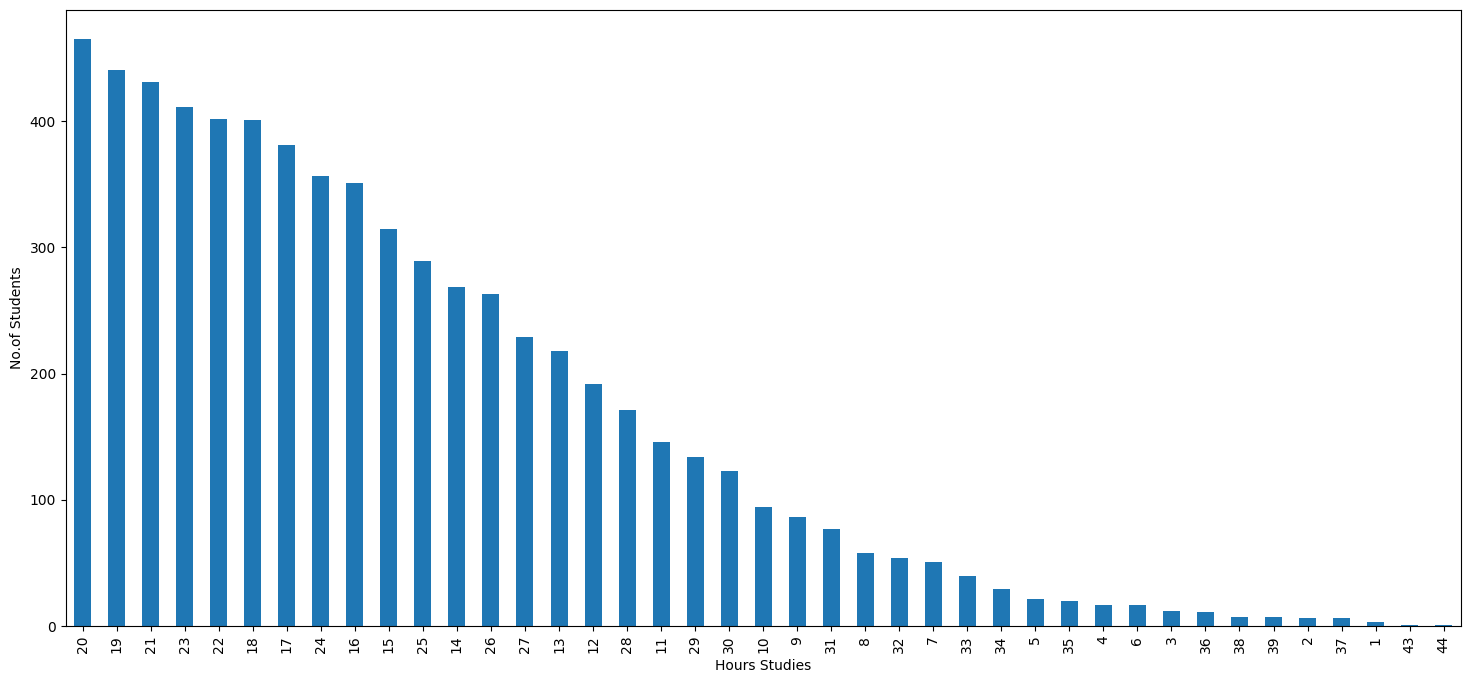

In [17]:
# Visualizing Each Columns for more insights
plt.subplots(figsize=(15,5))
data_copy['Hours_Studied'].value_counts(normalize=True)
data_copy['Hours_Studied'].value_counts(dropna=False).plot.bar(figsize=(18,8))
plt.xlabel('Hours Studies')
plt.ylabel('No.of Students')
plt.show()

We can Continue getting more insights about the columns, but dropping the columns that doesnt give much Correlation with the output seems wiser, while applying models like Regression but it may not be true for other models like decision trees or neural nets.

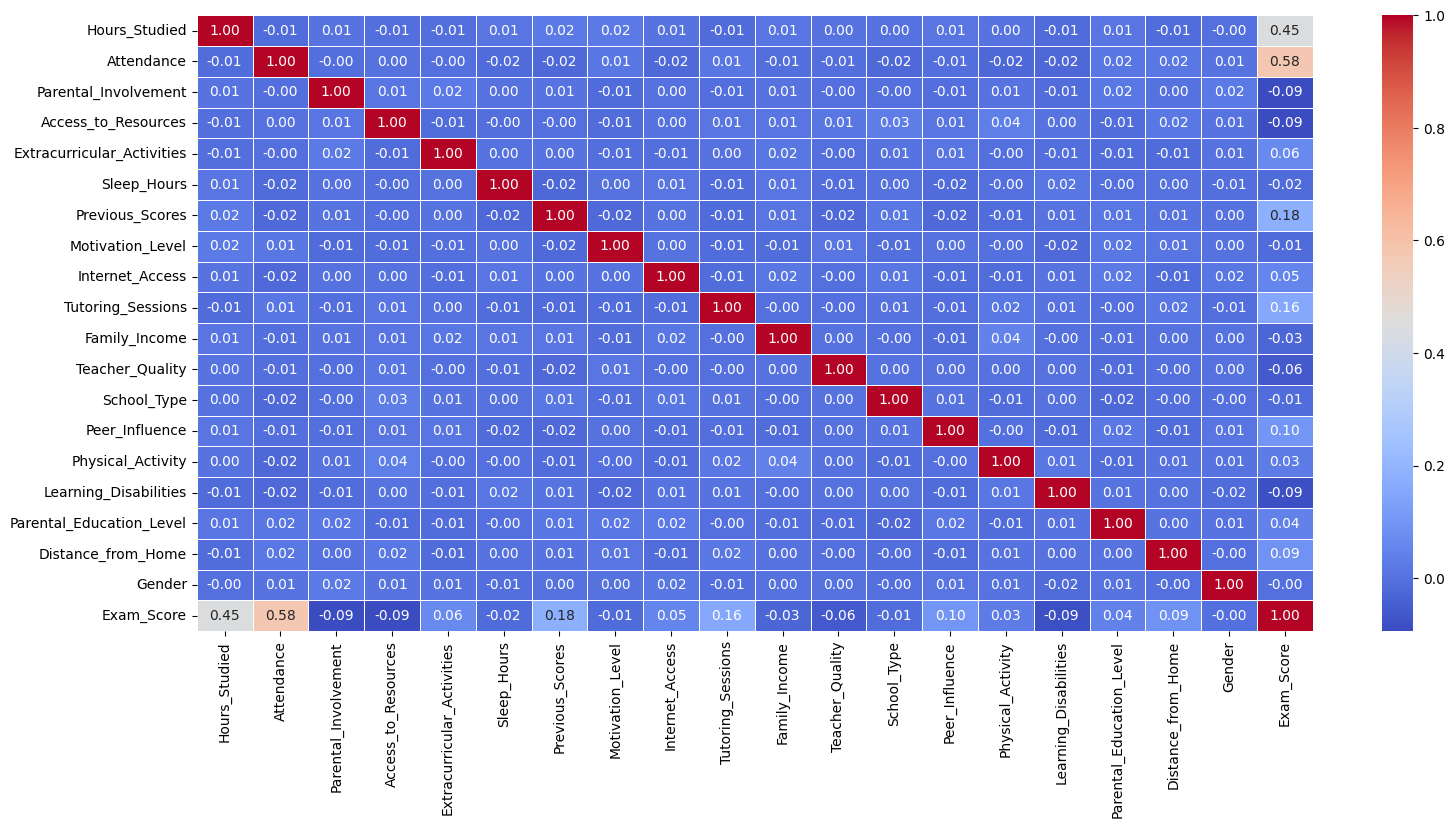

In [18]:
# making correlation heatmap for better visualization
plt.figure(figsize=(18,8))
sns.heatmap(data_copy.corr(),annot = True,cmap= 'coolwarm',fmt=".2f", linewidths=0.5)
plt.show()